In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [2]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by Pathologist

In [3]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator3', 'evaluator4', 'evaluator5']
correct_answers_eval_data = []
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathvqa_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data.append(eval_data)

Combining all the dataframes into one combined dataframe

In [4]:
correct_answers_eval_data_combined = correct_answers_eval_data[0] + correct_answers_eval_data[1] + correct_answers_eval_data[2] + correct_answers_eval_data[3]
correct_answers_eval_data_combined

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation    488      250      104       42   
            Visual Grounding            488      262       86       50   
Close-Ended Visual Grounding             40       22        4        0   

                                      Level -1  
Open-Ended  Knowledge Interpretation        92  
            Visual Grounding                90  
Close-Ended Visual Grounding                14

#### Correct Answer

Open-Ended Correct Answers Graph

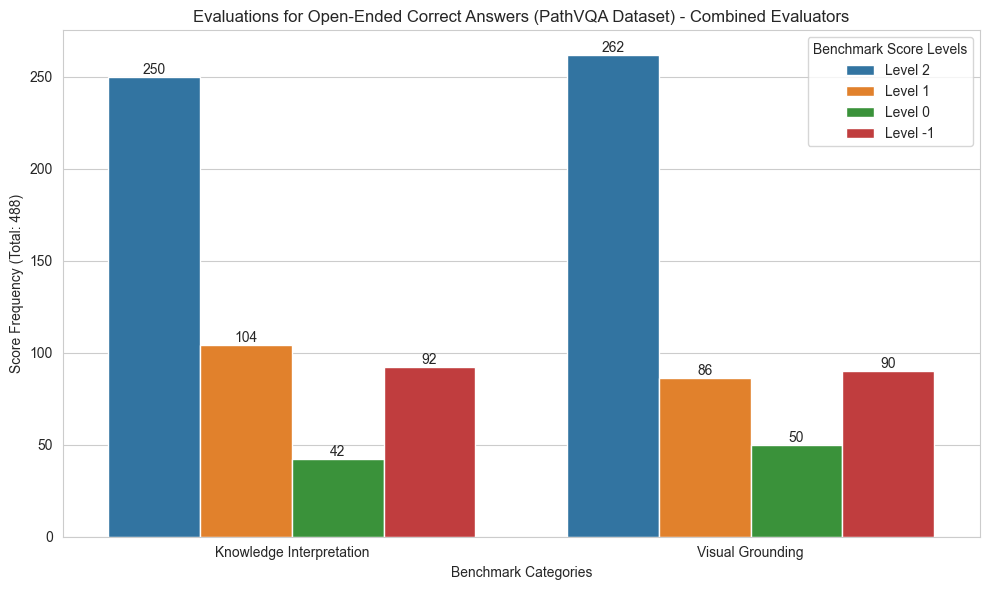

In [5]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Open-Ended Correct Answers (PathVQA Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined.loc["Open-Ended"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_open_ended_correct_answers.png')
plt.show()

Close-Ended Correct Answers Graph

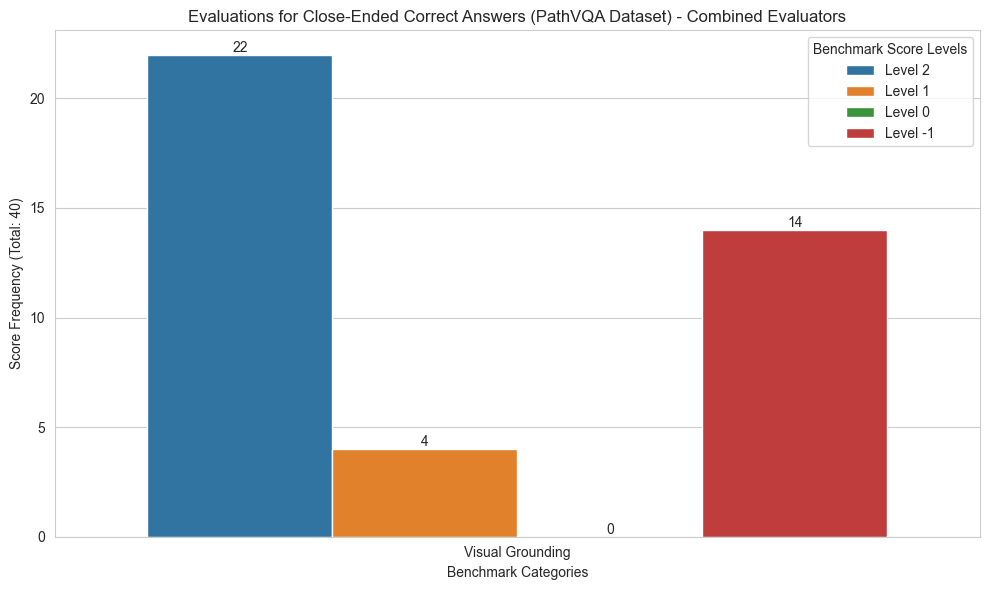

In [6]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Close-Ended Correct Answers (PathVQA Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined.loc["Close-Ended"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_close_ended_correct_answers.png')
plt.show()